In [ ]:
# Cell 0: Install (if needed) and import libraries
# Run in Colab: uncomment install lines if packages missing.
# !pip install geopandas folium scikit-learn matplotlib seaborn pyproj rtree

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Geo libs
import geopandas as gpd
from shapely.geometry import Point

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
import pandas as pd

# Load your Excel file
file_path = "Hyderabad_Weather_Data.xlsx"
df = pd.read_excel(file_path)

# Show column names
print(df.columns.tolist())

# Display first few rows
df.head()


['district', 'mandal', 'date', 'rain (mm)', 'min temp (°c)', 'max temp (°c)', 'min humidity (%)', 'max humidity (%)', 'min wind speed (kmph)', 'max wind speed (kmph)']


,district,mandal,date,rain (mm),min temp (°c),max temp (°c),min humidity (%),max humidity (%),min wind speed (kmph),max wind speed (kmph)
0,Hyderabad,Amberpet,2021-06-01,0.0,26.7,36.5,38.9,74.9,0.0,12.6
1,Hyderabad,Amberpet,2021-06-02,4.3,23.7,35.9,38.8,94.6,0.0,13.3
2,Hyderabad,Amberpet,2021-06-03,0.0,25.3,34.3,48.2,83.1,0.0,11.9
3,Hyderabad,Amberpet,2021-06-04,0.0,25.0,32.3,49.6,84.8,0.0,7.9
4,Hyderabad,Amberpet,2021-06-05,1.2,24.9,33.7,48.3,90.3,0.0,10.1


Rows: 8304
Mandals: 16
Date range: 2021-06-01 00:00:00 to 2024-09-30 00:00:00


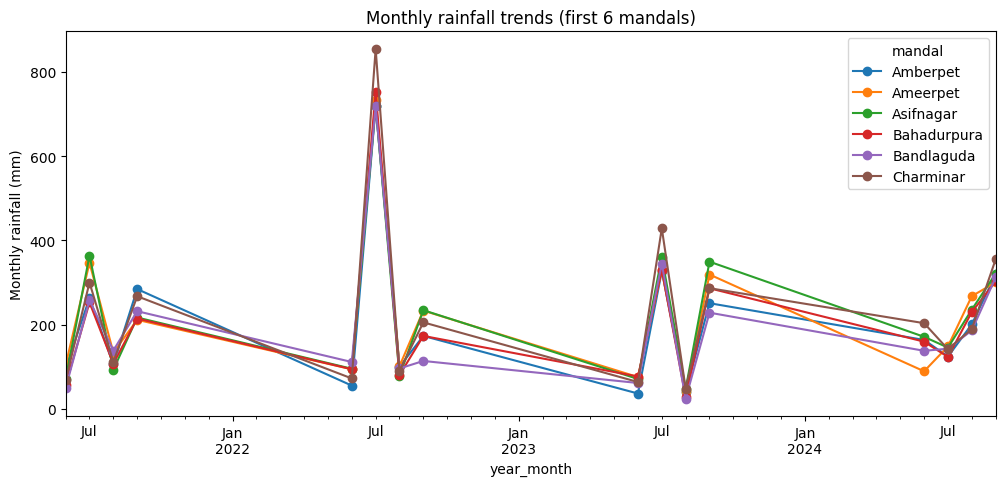

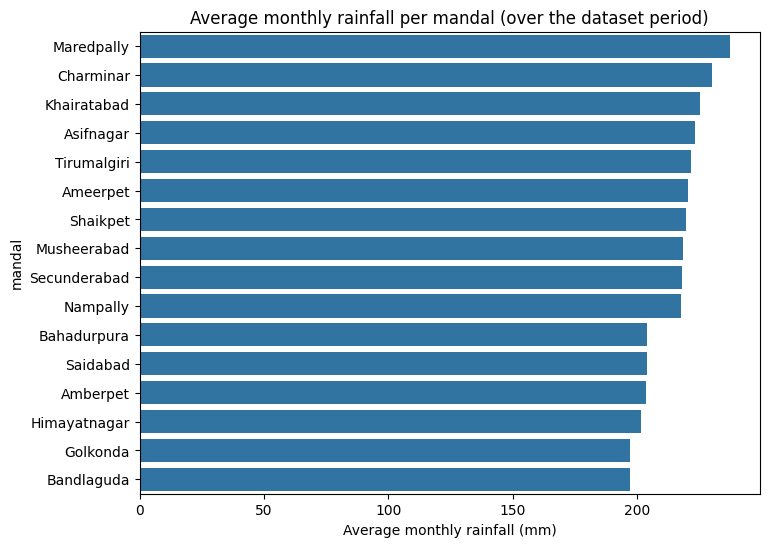

In [ ]:
# Cell 2: EDA - a few plots and summaries
print("Rows:", len(df))
print("Mandals:", df['mandal'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())

# monthly aggregator (assuming 'rain (mm)' column exists)
rain_col = [c for c in df.columns if 'rain' in c.lower()][0]
df['year_month'] = df['date'].dt.to_period('M')
monthly = df.groupby(['mandal','year_month'])[rain_col].sum().reset_index()
monthly_piv = monthly.pivot(index='year_month', columns='mandal', values=rain_col)

# plot first 6 mandals
ax = monthly_piv.iloc[:, :6].plot(figsize=(12,5), marker='o')
ax.set_ylabel("Monthly rainfall (mm)")
ax.set_title("Monthly rainfall trends (first 6 mandals)")
plt.show()

# heatmap of average rainfall per mandal across months
avg_by_mandal = monthly_piv.mean().sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=avg_by_mandal.values, y=avg_by_mandal.index)
plt.title("Average monthly rainfall per mandal (over the dataset period)")
plt.xlabel("Average monthly rainfall (mm)")
plt.show()

In [ ]:
import geopandas as gpd

# Path to your uploaded GeoJSON file
geojson_path = "HYDERABAD.geojson"

# Load mandal boundaries
mandal_map = gpd.read_file(geojson_path)

# Display structure
mandal_map.head()


,Name,Ward_No,Zone,Mandal,City,geometry
0,Suraram,129,Greater Hyderabad Municipal Corporation North ...,Quthbullapur mandal,Hyderabad,"POLYGON ((78.44763 17.51106, 78.44566 17.51161..."
1,Sanath Nagar,100,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.43827 17.44758, 78.43812 17.44787..."
2,Bholakpur,88,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.48809 17.42008, 78.48836 17.41967..."
3,Erragadda,101,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.41844 17.45063, 78.42043 17.45017..."
4,Rahmath Nagar,102,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.41206 17.44586, 78.41478 17.44561..."


In [ ]:
import pandas as pd

# Load your rainfall Excel file
rainfall_path = "Hyderabad_Weather_Data.xlsx"
rain_df = pd.read_excel(rainfall_path)

# Display columns to verify
print("Rainfall data columns:", rain_df.columns.tolist())

# Display first few rows
rain_df.head()


Rainfall data columns: ['district', 'mandal', 'date', 'rain (mm)', 'min temp (°c)', 'max temp (°c)', 'min humidity (%)', 'max humidity (%)', 'min wind speed (kmph)', 'max wind speed (kmph)']


,district,mandal,date,rain (mm),min temp (°c),max temp (°c),min humidity (%),max humidity (%),min wind speed (kmph),max wind speed (kmph)
0,Hyderabad,Amberpet,2021-06-01,0.0,26.7,36.5,38.9,74.9,0.0,12.6
1,Hyderabad,Amberpet,2021-06-02,4.3,23.7,35.9,38.8,94.6,0.0,13.3
2,Hyderabad,Amberpet,2021-06-03,0.0,25.3,34.3,48.2,83.1,0.0,11.9
3,Hyderabad,Amberpet,2021-06-04,0.0,25.0,32.3,49.6,84.8,0.0,7.9
4,Hyderabad,Amberpet,2021-06-05,1.2,24.9,33.7,48.3,90.3,0.0,10.1


In [ ]:
# Rename columns if necessary for easy merging
rain_df.rename(columns={'mandal': 'Mandal'}, inplace=True)

# Merge rainfall data with map
merged_data = mandal_map.merge(rain_df, on='Mandal', how='left')

# Check merged structure
merged_data.head()

,Name,Ward_No,Zone,Mandal,City,geometry,district,date,rain (mm),min temp (°c),max temp (°c),min humidity (%),max humidity (%),min wind speed (kmph),max wind speed (kmph)
0,Suraram,129,Greater Hyderabad Municipal Corporation North ...,Quthbullapur mandal,Hyderabad,"POLYGON ((78.44763 17.51106, 78.44566 17.51161...",NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sanath Nagar,100,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.43827 17.44758, 78.43812 17.44787...",Hyderabad,2021-06-01,0.0,25.9,37.5,37.9,76.9,0.0,8.8
2,Sanath Nagar,100,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.43827 17.44758, 78.43812 17.44787...",Hyderabad,2021-06-02,17.1,23.4,37.4,39.7,95.3,0.0,7.2
3,Sanath Nagar,100,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.43827 17.44758, 78.43812 17.44787...",Hyderabad,2021-06-03,9.7,23.0,35.7,46.6,94.5,0.0,4.9
4,Sanath Nagar,100,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.43827 17.44758, 78.43812 17.44787...",Hyderabad,2021-06-04,0.0,24.5,32.8,50.8,88.5,0.0,3.3


<Figure size 1000x1000 with 0 Axes>

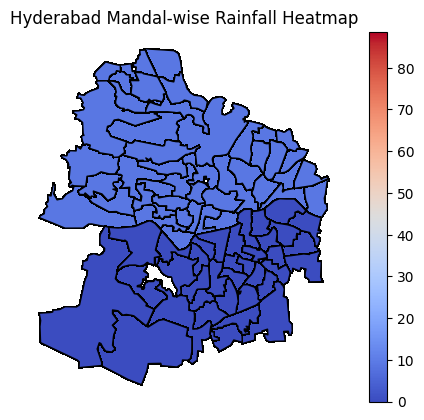

In [ ]:
import matplotlib.pyplot as plt

# Plot rainfall heatmap
plt.figure(figsize=(10, 10))
merged_data.plot(column='rain (mm)', cmap='coolwarm', legend=True, edgecolor='black')
plt.title("Hyderabad Mandal-wise Rainfall Heatmap")
plt.axis('off')
plt.show()

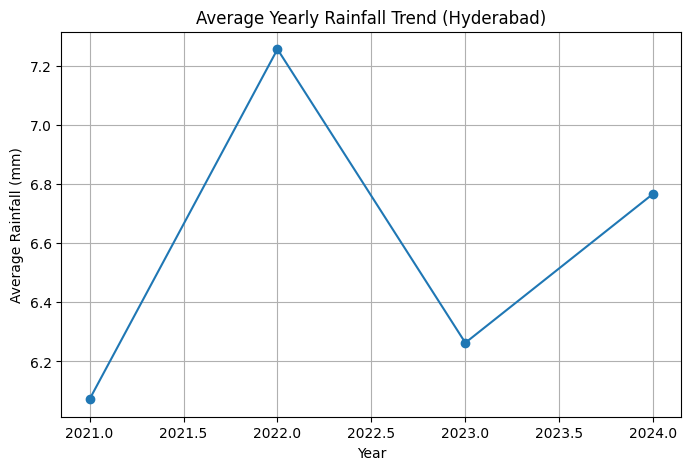

In [ ]:
# Convert date if needed
if 'date' in rain_df.columns:
    rain_df['Year'] = rain_df['date'].dt.year

# Group by year
rainfall_trend = rain_df.groupby('Year')['rain (mm)'].mean()

# Plot trend
plt.figure(figsize=(8, 5))
rainfall_trend.plot(marker='o')
plt.title("Average Yearly Rainfall Trend (Hyderabad)")
plt.xlabel("Year")
plt.ylabel("Average Rainfall (mm)")
plt.grid(True)
plt.show()

In [ ]:
# Cell 3: Load mandal GeoJSON/Shapefile and compute centroids
# MANUAL STEP: Download Telangana Mandal GeoJSON or Shapefile from:
# - Telangana portal (Telangana District and Mandal Shape Files) or
# - AIKosh dataset (Telangana district & mandal geospatial shapefiles)
# Save it locally and set path below to the downloaded file.

# Example path (after you download):
mandal_geo_path = "HYDERABAD.geojson"  # <<-- replace with real path

# If you already have GHMC wards / mandal shapefile, use that.
gdf_mandals = gpd.read_file(mandal_geo_path)
gdf_mandals = gdf_mandals.to_crs(epsg=4326)  # ensure lat/lon

# Show columns and sample names to find matching name field (e.g., 'mandal_name' or 'NAME')
print(gdf_mandals.columns)
display(gdf_mandals.head())

# Compute centroid lat/lon for each mandal for API queries
gdf_mandals['centroid'] = gdf_mandals.geometry.centroid
gdf_mandals['lon'] = gdf_mandals.centroid.x
gdf_mandals['lat'] = gdf_mandals.centroid.y

# Keep a mapping of mandal name normalization for joining later
# Example: if gdf_mandals uses 'MANDAL' column - adjust accordingly
name_col = [c for c in gdf_mandals.columns if 'mandal' in c.lower() or 'name' in c.lower()][0]
gdf_mandals = gdf_mandals.rename(columns={name_col: 'mandal_name'})
gdf_mandals[['mandal_name','lat','lon']].head()


Index(['Name', 'Ward_No', 'Zone', 'Mandal', 'City', 'geometry'], dtype='object')


,Name,Ward_No,Zone,Mandal,City,geometry
0,Suraram,129,Greater Hyderabad Municipal Corporation North ...,Quthbullapur mandal,Hyderabad,"POLYGON ((78.44763 17.51106, 78.44566 17.51161..."
1,Sanath Nagar,100,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.43827 17.44758, 78.43812 17.44787..."
2,Bholakpur,88,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.48809 17.42008, 78.48836 17.41967..."
3,Erragadda,101,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.41844 17.45063, 78.42043 17.45017..."
4,Rahmath Nagar,102,Greater Hyderabad Municipal Corporation Centra...,Khairatabad,Hyderabad,"POLYGON ((78.41206 17.44586, 78.41478 17.44561..."


/tmp/ipython-input-496073850.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mandals['centroid'] = gdf_mandals.geometry.centroid
/tmp/ipython-input-496073850.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mandals['lon'] = gdf_mandals.centroid.x
/tmp/ipython-input-496073850.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mandals['lat'] = gdf_mandals.centroid.y


,mandal_name,lat,lon
0,Suraram,17.540024,78.427055
1,Sanath Nagar,17.454702,78.442177
2,Bholakpur,17.418203,78.495229
3,Erragadda,17.452841,78.428551
4,Rahmath Nagar,17.445529,78.419458


In [ ]:
# Cell 4: instructions (no code)
print("""
Download suggestions (manual):
1) Telangana district and mandal shapefiles (Telangana open data portal): use that to get mandal boundaries.
2) AIKosh / GitHub mirrors for Telangana mandal GeoJSON.

Once downloaded, set 'mandal_geo_path' in the previous cell and run Cell 3.
""")



Download suggestions (manual):
1) Telangana district and mandal shapefiles (Telangana open data portal): use that to get mandal boundaries.
2) AIKosh / GitHub mirrors for Telangana mandal GeoJSON.

Once downloaded, set 'mandal_geo_path' in the previous cell and run Cell 3.



In [ ]:
import numpy as np
import pandas as pd

# Copy mandal and year info from rainfall dataset
mandal_col = 'Mandal'  # replace with exact column name if different
if mandal_col not in rain_df.columns:
    print("Check your mandal column name in rainfall data first!")

# Get unique mandals and years
mandals = rain_df[mandal_col].unique()
years = sorted(rain_df['Year'].unique())

# Create a base dataframe for all mandals, months, and years
traffic_data = []
for mandal in mandals:
    for year in years:
        for month in range(1, 13):
            # Estimate baseline traffic per mandal type
            base = 60 if mandal.lower() in ['ameerpet', 'banjara hills', 'secunderabad', 'jubilee hills'] else 40

            # Add weather influence: assume higher rainfall → higher congestion
            month_rain = rain_df[
                (rain_df[mandal_col] == mandal) &
                (pd.to_datetime(rain_df['date']).dt.month == month) &
                (rain_df['Year'] == year)
            ]['rain (mm)'].mean()
            month_rain = month_rain if not np.isnan(month_rain) else np.random.uniform(10, 100)

            # Estimated traffic index formula
            traffic_index = base + (month_rain / 5) + np.random.uniform(-5, 5)
            traffic_index = np.clip(traffic_index, 10, 100)

            traffic_data.append([mandal, year, month, round(traffic_index, 2)])

traffic_df = pd.DataFrame(traffic_data, columns=['Mandal', 'Year', 'Month', 'Traffic_Index'])

# Save dummy data for reuse
traffic_df.to_csv("Dummy_Traffic_Index.csv", index=False)

traffic_df

,Mandal,Year,Month,Traffic_Index
0,Amberpet,2021,1,53.76
1,Amberpet,2021,2,52.48
2,Amberpet,2021,3,57.46
3,Amberpet,2021,4,55.40
4,Amberpet,2021,5,59.68
...,...,...,...,...
763,Tirumalgiri,2024,8,37.60
764,Tirumalgiri,2024,9,44.99
765,Tirumalgiri,2024,10,45.90
766,Tirumalgiri,2024,11,59.85


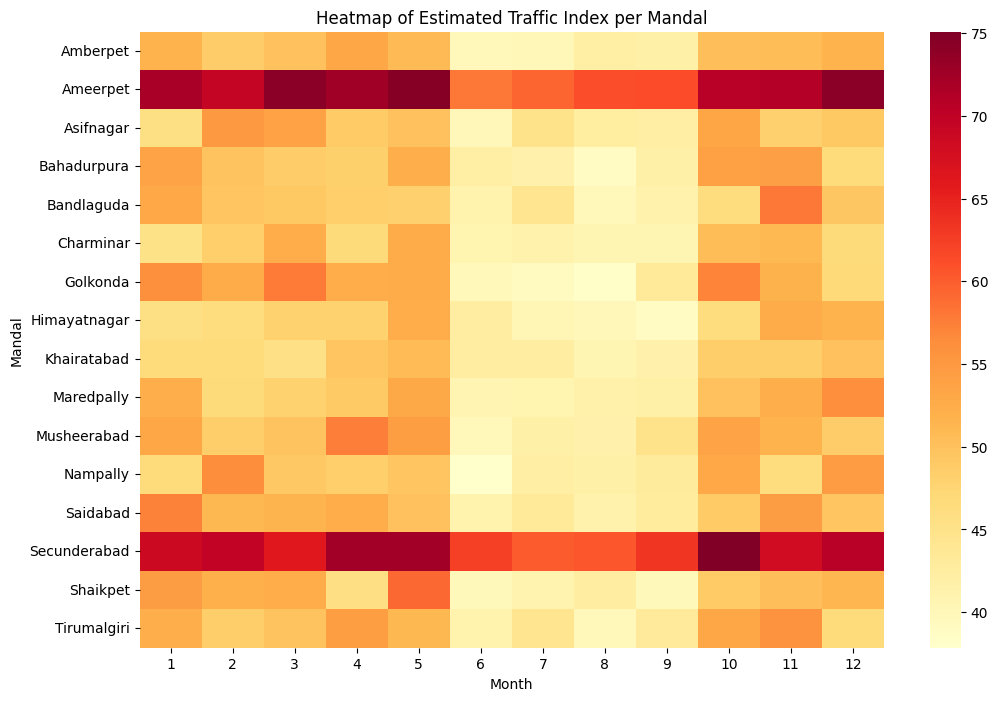

In [ ]:
pivot_df = traffic_df.pivot_table(index='Mandal', columns='Month', values='Traffic_Index', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap='YlOrRd', annot=False)
plt.title("Heatmap of Estimated Traffic Index per Mandal")
plt.xlabel("Month")
plt.ylabel("Mandal")
plt.show()


In [ ]:
# Cell 5: Traffic data options & code templates

# Option A: If you found an official CSV with columns: [mandal, date, vehicle_count]
# Put it under /mnt/data/traffic_mandal.csv and run:
traffic_path = "Dummy_Traffic_Index.csv"
if os.path.exists(traffic_path):
    df_traffic = pd.read_csv(traffic_path) # Removed parse_dates=['date']
    print("Loaded traffic:", df_traffic.shape)
else:
    print("No local traffic CSV found at", traffic_path)
    print("If you have a CSV from Telangana / GHMC, use that path and reload.")

# Option B: If only ward-level GHMC data exists, you can aggregate/convert ward->mandal
# using spatial join between ward shapefile and mandal shapefile (use geopandas.sjoin).
#
# Example (do after loading ward_gdf and gdf_mandals):
# ward_gdf = gpd.read_file('/path/to/ghmc_wards.geojson').to_crs(epsg=4326)
# ward_gdf['centroid'] = ward_gdf.geometry.centroid
# join = gpd.sjoin(ward_gdf, gdf_mandals[['mandal_name','geometry']], predicate='within', how='left')
# then aggregate counts from ward-level traffic to mandal-level

Loaded traffic: (768, 4)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 9: Train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Prepare data for model training
# Define features (X) and target variable (Y)
# Features could include rainfall, traffic count, complaints, and time-based features like day of week and month.

# Let's create a target variable for traffic level based on 'rain (mm)'
# This is a simplified example, you might need a more sophisticated method for real-world data
df['Traffic_Level'] = pd.cut(df['rain (mm)'],
                                   bins=[-np.inf, 10, 50, 100, np.inf], # Adjusted bins for rainfall
                                   labels=['low', 'moderate', 'high', 'very high'],
                                   right=False)

# Convert categorical target to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Traffic_Level_Encoded'] = le.fit_transform(df['Traffic_Level'])

# Define features (X) and target (Y)
features = ['rain (mm)'] # Example features
X = df[features].copy() # Create a copy to avoid SettingWithCopyWarning

# Add time-based features - ensure 'date' column exists and is datetime
if 'date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['date']):
    X['DayOfWeek'] = df['date'].dt.dayofweek
    X['Month'] = df['date'].dt.month
else:
    print("Warning: 'date' column not found or not in datetime format. Time-based features will not be added.")


Y = df['Traffic_Level_Encoded']

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

X_train shape: (6643, 3)
X_test shape: (1661, 3)
Y_train shape: (6643,)
Y_test shape: (1661,)
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        54
           1       1.00      1.00      1.00      1323
           2       1.00      1.00      1.00       283
           3       1.00      1.00      1.00         1

    accuracy                           1.00      1661
   macro avg       0.99      0.99      0.99      1661
weighted avg       1.00      1.00      1.00      1661

Confusion Matrix:
[[  53    0    1    0]
 [   0 1323    0    0]
 [   1    0  282    0]
 [   0    0    0    1]]


In [ ]:
# Cell 8: Prepare data for model training
# Define features (X) and target variable (Y)
# Features could include rainfall, traffic count, complaints, and time-based features like day of week and month.

# The data preparation code has been moved to Cell 9 to fix the NameError.